# GCI World Final Assignment — Reproducible Analysis

**Business proposal:** Proactive churn retention for Company A (telecom).

Run all cells top-to-bottom. Requires `telecom/Client.csv` and `telecom/Record.csv` in the project folder.

| Section | Contents                            |
| ------- | ----------------------------------- |
| 1       | Setup & data loading                |
| 2       | EDA (charts for slides)             |
| 3       | Feature engineering & preprocessing |
| 4       | Models (XGBoost + LightGBM)         |
| 5       | Feature importance                  |
| 6       | Business ROI calculator             |


## 1. Setup & Data Loading


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

# Resolve paths whether notebook is run from project root or a subfolder
ROOT = Path.cwd()
if not (ROOT / "telecom" / "Client.csv").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "telecom"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

print(f"Project root: {ROOT}")

Project root: /home/farout101/Documents/GitHub/GCI World/final_assignment/Final Assignment


In [2]:
client = pd.read_csv(DATA_DIR / "Client.csv")
record = pd.read_csv(DATA_DIR / "Record.csv")

df = record.merge(client, on="Customer_ID", how="inner")
assert len(df) == 100_000, f"Expected 100k rows, got {len(df)}"

print(f"Merged shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.1%}")
df.head(3)

Merged shape: (100000, 100)
Churn rate: 49.6%


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.0,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.0,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.0,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0


## 2. Exploratory Data Analysis

Charts below map directly to slides 5–6 in `slides_outline.md`.


churn
0    50438
1    49562
Name: count, dtype: int64

Churn distribution:
  0: 50,438 (50.4%)
  1: 49,562 (49.6%)


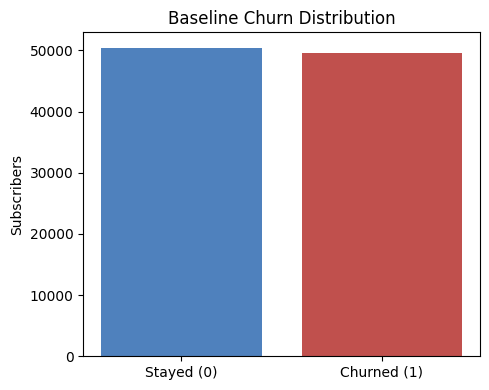

In [14]:
# --- 2a. Target balance ---
churn_counts = df["churn"].value_counts().sort_index()
print(f"{churn_counts}\n")
print("Churn distribution:")
for label, count in churn_counts.items():
    print(f"  {label}: {count:,} ({count / len(df):.1%})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Stayed (0)", "Churned (1)"], churn_counts.values, color=["#4F81BD", "#C0504D"]) # type: ignore
ax.set_ylabel("Subscribers")
ax.set_title("Baseline Churn Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_churn_distribution.png", dpi=150)
plt.show()

Months 6–10 churn:  33.8%
Months 11–12 churn: 63.7%  (delta: +29.9 pp)


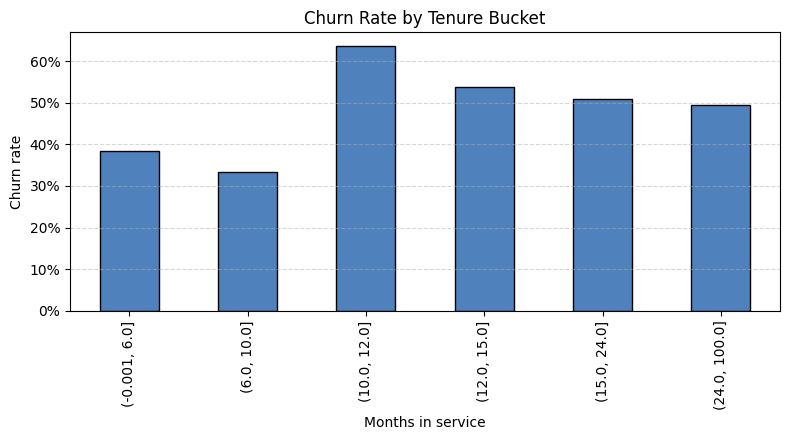

In [ ]:
# --- 2b. Contract cliff (tenure) ---
df["months_bucket"] = pd.cut(
    df["months"], bins=[0, 6, 10, 12, 15, 24, 100], include_lowest=True
)
tenure_churn = df.groupby("months_bucket", observed=False)["churn"].mean()

m6_10 = df[(df["months"] >= 6) & (df["months"] <= 10)]["churn"].mean()
m11_12 = df[(df["months"] >= 11) & (df["months"] <= 12)]["churn"].mean()
print(f"Months 6–10 churn:  {m6_10:.1%}")
print(f"Months 11–12 churn: {m11_12:.1%}  (delta: +{(m11_12 - m6_10)*100:.1f} pp)")

fig, ax = plt.subplots(figsize=(8, 4.5))
tenure_churn.plot(kind="bar", ax=ax, color="#4F81BD", edgecolor="black")
ax.set_title("Churn Rate by Tenure Bucket")
ax.set_xlabel("Months in service")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}")) # type: ignore
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_tenure_churn.png", dpi=150)
plt.show()

Handset <= $50 churn:  57.5%
Handset >  $200 churn: 36.0%
Equipment > 270 days:   54.9%


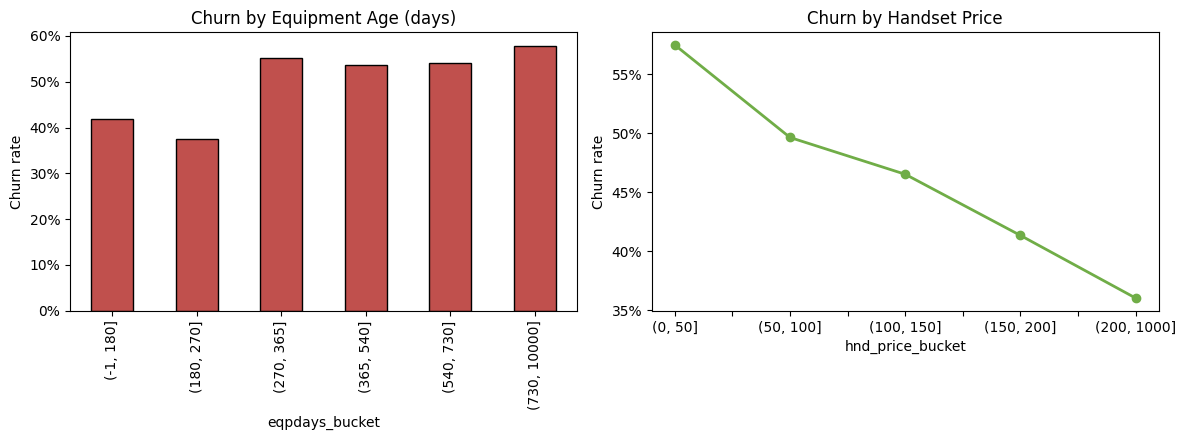

In [6]:
# --- 2c. Equipment age & handset price ---
df["eqpdays_bucket"] = pd.cut(
    df["eqpdays"], bins=[-1, 180, 270, 365, 540, 730, 10_000]
)
eqp_churn = df.groupby("eqpdays_bucket", observed=False)["churn"].mean()

df["hnd_price_bucket"] = pd.cut(
    df["hnd_price"], bins=[0, 50, 100, 150, 200, 1_000]
)
hnd_churn = df.groupby("hnd_price_bucket", observed=False)["churn"].mean()

print(f"Handset <= $50 churn:  {df.loc[df['hnd_price'] <= 50, 'churn'].mean():.1%}")
print(f"Handset >  $200 churn: {df.loc[df['hnd_price'] > 200, 'churn'].mean():.1%}")
print(f"Equipment > 270 days:   {df.loc[df['eqpdays'] > 270, 'churn'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
eqp_churn.plot(kind="bar", ax=axes[0], color="#C0504D", edgecolor="black")
axes[0].set_title("Churn by Equipment Age (days)")
axes[0].set_ylabel("Churn rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

hnd_churn.plot(kind="line", marker="o", ax=axes[1], color="#70AD47", linewidth=2)
axes[1].set_title("Churn by Handset Price")
axes[1].set_ylabel("Churn rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig(FIG_DIR / "03_device_churn.png", dpi=150)
plt.show()

Stayers: change_mou=-5.3, rev_Mean=$59.22/mo
Churners: change_mou=-22.8, rev_Mean=$58.21/mo

Monthly revenue at risk (all churners): $2.87M


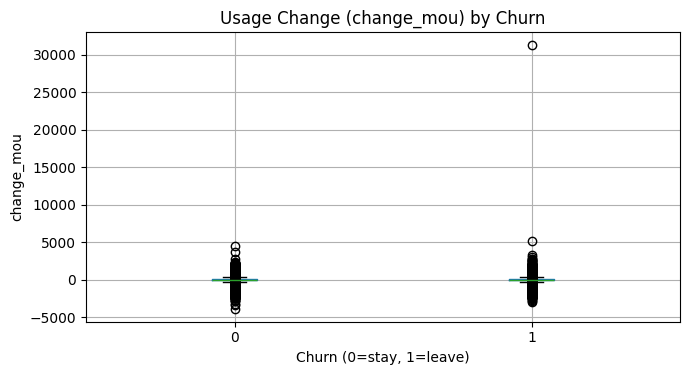

In [7]:
# --- 2d. Usage decline & revenue at risk ---
for churn_val, label in [(0, "Stayers"), (1, "Churners")]:
    subset = df[df["churn"] == churn_val]
    print(
        f"{label}: change_mou={subset['change_mou'].mean():.1f}, "
        f"rev_Mean=${subset['rev_Mean'].mean():.2f}/mo"
    )

monthly_rev_at_risk = df.loc[df["churn"] == 1, "rev_Mean"].sum()
print(f"\nMonthly revenue at risk (all churners): ${monthly_rev_at_risk/1e6:.2f}M")

fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="change_mou", by="churn", ax=ax)
ax.set_title("Usage Change (change_mou) by Churn")
ax.set_xlabel("Churn (0=stay, 1=leave)")
ax.set_ylabel("change_mou")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_change_mou_by_churn.png", dpi=150)
plt.show()

## 3. Feature Engineering & Preprocessing


In [8]:
EDA_COLS = ["months_bucket", "eqpdays_bucket", "hnd_price_bucket"]
df_model = df.drop(columns=["Customer_ID"] + EDA_COLS).copy()

# Business-aligned engineered features
df_model["upgrade_eligible"] = (df_model["eqpdays"] >= 270).astype(int)
df_model["bill_shock_risk"] = (df_model["vceovr_Mean"] >= 20.0).astype(int)
df_model["severe_usage_drop"] = (df_model["change_mou"] <= -100.0).astype(int)
df_model["eqp_tenure_ratio"] = df_model["eqpdays"] / (df_model["months"] * 30.0 + 1)
df_model["is_budget_phone"] = (df_model["hnd_price"] <= 50.0).astype(int)
df_model["contract_cliff_window"] = df_model["months"].between(9, 10).astype(int)

X = df_model.drop(columns="churn")
y = df_model["churn"]

for col in X.select_dtypes(include=[np.number]).columns:
    X[col] = X[col].fillna(X[col].median())

for col in X.select_dtypes(exclude=[np.number]).columns:
    X[col] = X[col].fillna("Unknown").astype(str)
    X[col] = LabelEncoder().fit_transform(X[col])

print(f"Feature matrix: {X.shape}")
print(f"Engineered features: upgrade_eligible, bill_shock_risk, severe_usage_drop, "
      f"eqp_tenure_ratio, is_budget_phone, contract_cliff_window")

Feature matrix: (100000, 104)
Engineered features: upgrade_eligible, bill_shock_risk, severe_usage_drop, eqp_tenure_ratio, is_budget_phone, contract_cliff_window


## 4. Model Training & Evaluation

**Slide requirement:** report model name, metric, and numeric score.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    eval_metric="logloss",
    random_state=42,
)
lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    random_state=42,
    verbose=-1,
)

xgb.fit(X_train, y_train)
lgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
lgb_proba = lgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)
lgb_pred = (lgb_proba >= 0.5).astype(int)

results = pd.DataFrame(
    {
        "Model": ["XGBoost Classifier", "LightGBM Classifier"],
        "Accuracy": [
            accuracy_score(y_test, xgb_pred),
            accuracy_score(y_test, lgb_pred),
        ],
        "ROC-AUC": [roc_auc_score(y_test, xgb_proba), roc_auc_score(y_test, lgb_proba)],
    }
)
results["Accuracy"] = results["Accuracy"].map(lambda x: f"{x:.1%}")
results["ROC-AUC"] = results["ROC-AUC"].map(lambda x: f"{x:.4f}")

print("=== MODEL RESULTS (copy to Slide 8) ===")
print(results.to_string(index=False))
print("\nSelected model: LightGBM Classifier")
print(classification_report(y_test, lgb_pred, target_names=["Stay", "Churn"]))

=== MODEL RESULTS (copy to Slide 8) ===
              Model Accuracy ROC-AUC
 XGBoost Classifier    63.8%  0.6939
LightGBM Classifier    63.7%  0.6926

Selected model: LightGBM Classifier
              precision    recall  f1-score   support

        Stay       0.64      0.62      0.63     15131
       Churn       0.63      0.65      0.64     14869

    accuracy                           0.64     30000
   macro avg       0.64      0.64      0.64     30000
weighted avg       0.64      0.64      0.64     30000



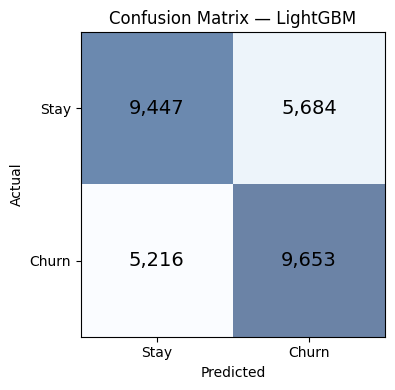

In [10]:
cm = confusion_matrix(y_test, lgb_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues", alpha=0.6)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1], labels=["Stay", "Churn"])
ax.set_yticks([0, 1], labels=["Stay", "Churn"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — LightGBM")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_confusion_matrix.png", dpi=150)
plt.show()

## 5. Feature Importance


Top 15 features (LightGBM):
change_mou          285
mou_Mean            229
months              202
totmrc_Mean         195
change_rev          182
eqpdays             147
avgqty              133
crclscod            117
avgrev              104
eqp_tenure_ratio    104
drop_vce_Mean       103
avgmou              103
ethnic              100
mou_cvce_Mean        98
hnd_price            94


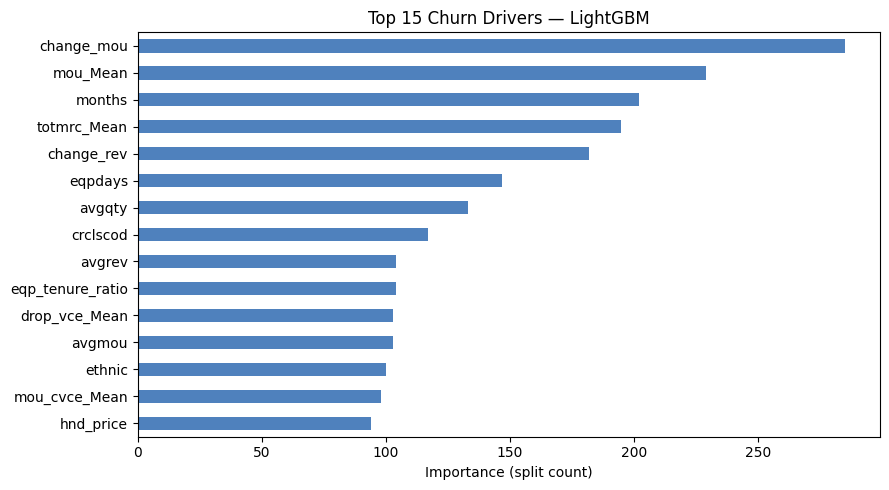

In [11]:
feat_imp = (
    pd.Series(lgb.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 features (LightGBM):")
print(feat_imp.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="#4F81BD")
ax.set_title("Top 15 Churn Drivers — LightGBM")
ax.set_xlabel("Importance (split count)")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_feature_importance.png", dpi=150)
plt.show()

## 6. Business ROI Calculator

Adjust the parameters below to match your slide assumptions.


In [12]:
def roi_case(
    n_targeted: int,
    subsidy_usd: float,
    acceptance_rate: float,
    precision: float,
    monthly_arpu: float,
) -> dict:
    """Conservative retention campaign ROI."""
    campaign_cost = n_targeted * subsidy_usd
    customers_saved = n_targeted * acceptance_rate * precision
    annual_rev_protected = customers_saved * monthly_arpu * 12
    net = annual_rev_protected - campaign_cost
    return {
        "targeted": n_targeted,
        "campaign_cost_usd": campaign_cost,
        "customers_saved": customers_saved,
        "annual_rev_protected_usd": annual_rev_protected,
        "net_usd": net,
    }


avg_monthly_arpu = df["rev_Mean"].mean()
high_value_arpu = df.loc[df["rev_Mean"] >= df["rev_Mean"].quantile(0.8), "rev_Mean"].mean()

base = roi_case(
    n_targeted=10_000,
    subsidy_usd=100,
    acceptance_rate=0.20,
    precision=0.65,
    monthly_arpu=avg_monthly_arpu,
)
high_value = roi_case(
    n_targeted=10_000,
    subsidy_usd=100,
    acceptance_rate=0.20,
    precision=0.65,
    monthly_arpu=high_value_arpu,
)

print("=== ROI SCENARIOS (copy to Slide 13) ===")
print(f"Average monthly ARPU: ${avg_monthly_arpu:.2f}")
print(f"Top-20% monthly ARPU: ${high_value_arpu:.2f}")
print()
for name, case in [("Base (avg ARPU)", base), ("High-value segment", high_value)]:
    print(name)
    for k, v in case.items():
        if "usd" in k:
            print(f"  {k}: ${v:,.0f}")
        elif k == "customers_saved":
            print(f"  {k}: {v:,.0f}")
        else:
            print(f"  {k}: {v:,}")
    print()

=== ROI SCENARIOS (copy to Slide 13) ===
Average monthly ARPU: $58.72
Top-20% monthly ARPU: $123.82

Base (avg ARPU)
  targeted: 10,000
  campaign_cost_usd: $1,000,000
  customers_saved: 1,300
  annual_rev_protected_usd: $916,032
  net_usd: $-83,968

High-value segment
  targeted: 10,000
  campaign_cost_usd: $1,000,000
  customers_saved: 1,300
  annual_rev_protected_usd: $1,931,639
  net_usd: $931,639



---

**Next steps for submission:**

1. Copy figures from `figures/` into your slide deck.
2. Fill in `slides_outline.md` with your market citations.
3. Rename notebook to `YourOmnicampusName.ipynb` before upload.
